## <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Análisis Multivariado</strong></span>




## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [1]:
# Solicitar datos al estudiante
# nombre = input("Ingresa tu nombre completo: ")
# nombre = "César Augusto Montoya Ocampo"
nombre = "Nelson Mauricio García López"
# correo = input("Ingresa tu correo electrónico: ")
# correo = "cesara.montoya1@udea.edu.co"
correo = "nelson.garcia@udea.edu.co"

# Mostrar los datos ingresados
print("\nResumen de datos ingresados:")
print(f"Nombre: {nombre}")
print(f"Correo electrónico: {correo}")


Resumen de datos ingresados:
Nombre: Nelson Mauricio García López
Correo electrónico: nelson.garcia@udea.edu.co


## <span style="color:black;"><strong>Parte 3: Análisis Multivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio1: Análisis de componentes principales</strong></span>

A partir de un conjunto de datos real sobre diamantes, realiza un análisis multivariado utilizando PCA para reducir la dimensionalidad y visualizar agrupamientos por calidad de corte.

1. Carga el conjunto de datos diamonds desde la librería seaborn `load_dataset("diamonds")`.
2. Selecciona las siguientes variables morfológicas para el análisis:
   - 'x': Longitud en mm.
   - 'y': Ancho en mm.
   - 'z': Altura en mm.
   - 'price': Precio en dólares.
   - 'carat': Peso del diamante.
3. Estandariza las variables seleccionadas usando StandardScaler.
4. Aplica PCA()
5. Imprime las ecuaciones que obtuviste para el número de componentes que utilizaste
6. Grafica los resultados en un plano bidimensional (PC1 vs PC2), diferenciando por calidad de corte.
7. Interpreta visualmente qué calidades de corte se agrupan o separan mejor en el espacio reducido.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from numpy.linalg import svd
from scipy.stats import shapiro
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

Base de datos original: (53940, 10)


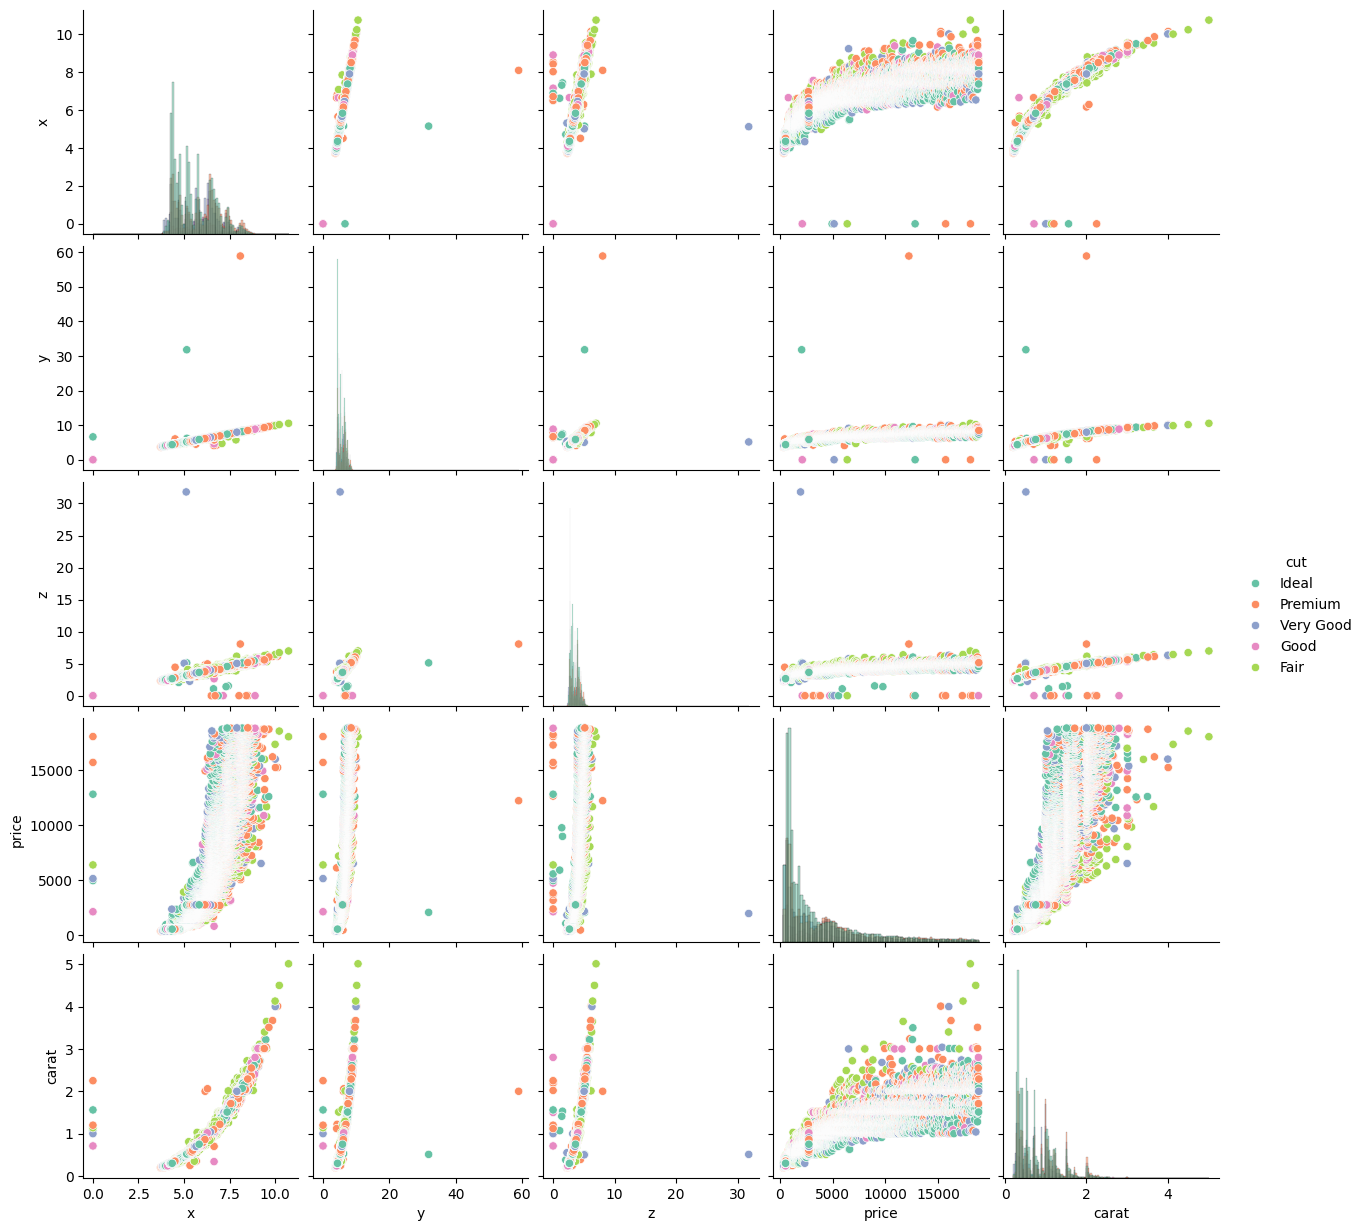

Ecuaciones de los componentes principales:

PC1 = 0.455·'x' + 0.449·'y' + 0.449·'z' + 0.428·'price' + 0.454·'carat'
PC2 = -0.235·'x' - 0.311·'y' - 0.33·'z' + 0.858·'price' + 0.06·'carat'
PC3 = 0.062·'x' + 0.713·'y' - 0.691·'z' + 0.016·'price' - 0.099·'carat'
PC4 = 0.231·'x' - 0.322·'y' - 0.428·'z' - 0.272·'price' + 0.765·'carat'
PC5 = 0.825·'x' - 0.299·'y' - 0.17·'z' + 0.083·'price' - 0.441·'carat'


In [3]:
db = sns.load_dataset("diamonds")
print(f"Base de datos original: {db.shape}")

# Realizar submuestreo para acelerar el proceso
# n_samples = 5000
# db = db.sample(n_samples, random_state=42)

# Seleccionar variables establecidas y la variable categórica 'cut'
feat_names = ["x", "y", "z", "price", "carat"]
output_col = "cut"
db = db[feat_names + [output_col]]
db.head()

# Hacer un pairplot para visualización de datos
sns.pairplot(db, hue=output_col, palette="Set2", diag_kind="hist", corner=False)
plt.show()

# Estandarizar las variables usando StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(db[feat_names])

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Matriz de componentes
components = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i + 1}" for i in range(len(feat_names))],
    index=feat_names,
)

# Ecuaciones de los componentes principales con nombres reales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(components.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join(
        [f"{round(pesos[j], 3)}·'{feat_names[j]}'" for j in range(len(pesos))]
    )
    ecuacion = ecuacion.replace("+ -", "- ")
    print(f"{comp} = {ecuacion}")

### <span style="color:red">Interpretación</span>

Del pairplot podemos observar ciertos comportamientos entre variables, comportamientos logarítmicos entre el peso y las dimensiones y exponenciales entre dimensiones y precio, sin embargo resulta completamente imposible diferenciar las categorías utilizando estas características.
Por otro lado, de las ecuaciones podemos observar que la componente principal 1 (PC1) le da un peso equitativo a cada característica usada, mientras que las demás sí escalan cada característica.

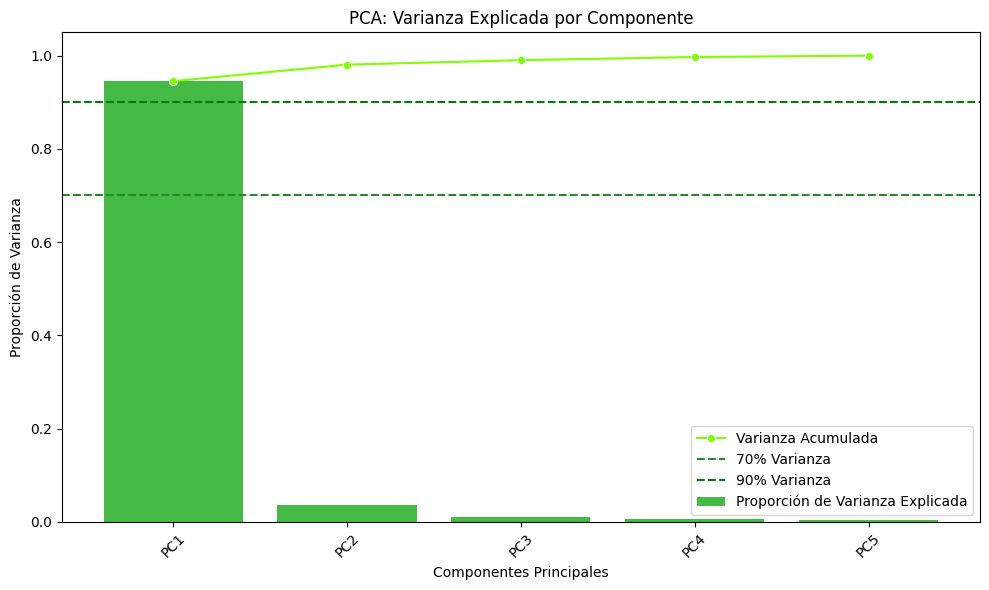

In [4]:
# Varianza explicada
variances = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_cum = np.cumsum(PVE)
components_names = [f"PC{i + 1}" for i in range(len(PVE))]

df_varianza = pd.DataFrame(
    {
        "Componente": components_names,
        "Varianza": variances,
        "PVE": PVE,
        "PVE Acumulada": PVE_cum,
    }
)
# Graficar la proporción de varianza explica por componente y la varianza acumulada
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Componente",
    y="PVE",
    data=df_varianza,
    color="limegreen",
    label="Proporción de Varianza Explicada",
)
sns.lineplot(
    x="Componente",
    y="PVE Acumulada",
    data=df_varianza,
    marker="o",
    color="chartreuse",
    label="Varianza Acumulada",
)
plt.axhline(0.7, color="forestgreen", linestyle="--", label="70% Varianza")
plt.axhline(0.9, color="green", linestyle="--", label="90% Varianza")
plt.title("PCA: Varianza Explicada por Componente")
plt.xlabel("Componentes Principales")
plt.ylabel("Proporción de Varianza")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color:red">Interpretación</span>

En el gráfico de varianza acumulada se nota que solamente la PC1 es representativa en términos de varianza explicada, lo que nos indica que las demás componentes no aportan para la variabilidad de los datos.

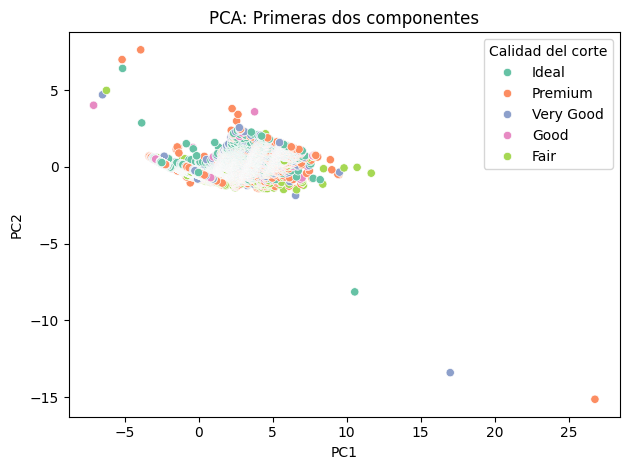

In [5]:
# Gráfico de las dos primeras componentes principales
df_pca = pd.DataFrame(X_pca, columns=components_names)

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=db[output_col], palette="Set2")
plt.title("PCA: Primeras dos componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.legend(title="Calidad del corte")
plt.show()

### <span style="color:red">Interpretación</span>

Como concluimos en la gráfica anterior, principalmente la PC1 es la que aporta a la variabilidad de los datos, de la gráfica podemos observar que el rango intercuartil de PC1 aparenta ser más amplio que el de PC2, esto sería una justificación para la alta explicación de la varianza de PC1 en comparación con el resto.

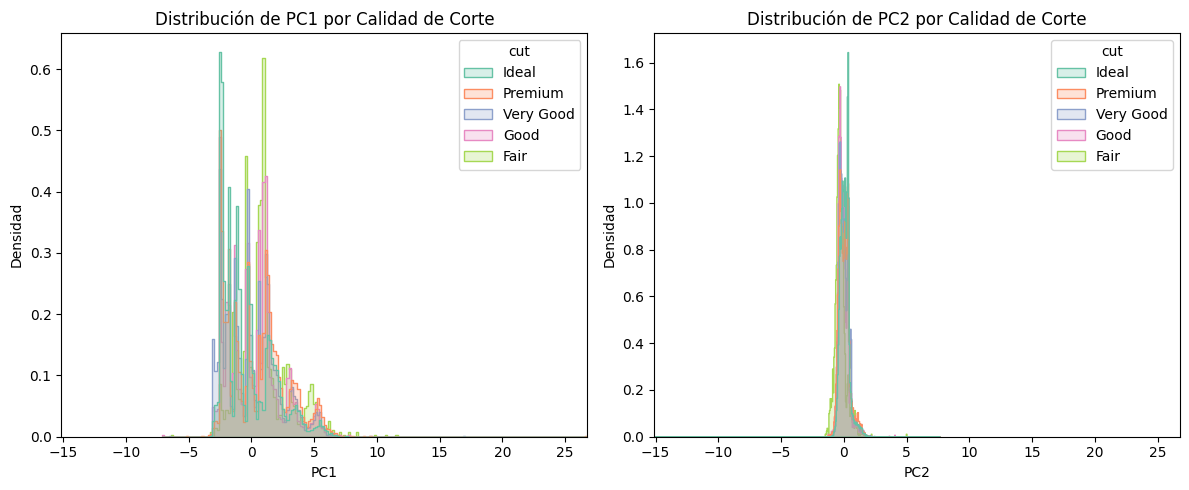

In [6]:
# Graficar histograma de valores para las dos primeras componentes principales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(
    data=df_pca,
    x="PC1",
    hue=db["cut"],
    element="step",
    stat="density",
    common_norm=False,
    palette="Set2",
)
plt.title("Distribución de PC1 por Calidad de Corte")
plt.xlabel("PC1")
plt.ylabel("Densidad")

plt.subplot(1, 2, 2)
sns.histplot(
    data=df_pca,
    x="PC2",
    hue=db["cut"],
    element="step",
    stat="density",
    common_norm=False,
    palette="Set2",
)
plt.title("Distribución de PC2 por Calidad de Corte")
plt.xlabel("PC2")
plt.ylabel("Densidad")

# Hacer que ambas gráficas tenga la misma escala en el eje x de manera dinámica en base a sus rangos
x_min = min(df_pca["PC1"].min(), df_pca["PC2"].min())
x_max = max(df_pca["PC1"].max(), df_pca["PC2"].max())

plt.subplot(1, 2, 1)
plt.xlim(x_min, x_max)
plt.subplot(1, 2, 2)
plt.xlim(x_min, x_max)

plt.tight_layout()
plt.show()

### <span style="color:red">Interpretación</span>

Ahora con más claridad podemos observar que la PC1 está más distribuida en su rango que la PC2, esto lo podemos deducir no solo visualmente si no también por los valores máximos de densidad del eje vertical, ya que un valor alto significa que la gráfica llega a densidades muy altas, valores muy concentrados, mientras que un valor bajo significan valores más repartidos en el rango.

### <span style="color:#2F749F;"><strong>Ejercicio 2: Regresión Lineal Múltiple</strong></span>  

A partir de un conjunto de datos real sobre consumo de combustible de automóviles, realiza un análisis de regresión lineal múltiple para predecir la  aceleración en función de variables numéricas relacionadas con sus características físicas.  

1. Carga el conjunto de datos `mpg` desde la librería seaborn `load_dataset("mpg")`.  
2. Selecciona las siguientes variables predictoras para el análisis:  
   - `displacement`  
   - `horsepower`  
   - `weight`     
3. Define como variable respuesta la aceleración (`acceleration`).  
4. Divide los datos en entrenamiento y prueba para validar el modelo.  
5. Ajusta un modelo de **Regresión Lineal Múltiple** usando `statsmodels.OLS()`.  
6. Imprime el resumen del modelo (coeficientes, significancia, R² ajustado, etc.).  
7. Evalúa el desempeño del modelo con métricas de ajuste como **RMSE** y **R²** en el conjunto de prueba.  
8. Grafica los valores reales vs. los valores predichos del precio para interpretar la calidad del ajuste.  

In [7]:
# Cargar datos
data = sns.load_dataset("mpg")
data = data.dropna()

# Mostrar primeras filas
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
# Variables de entrada
feat_names = ["displacement", "horsepower", "weight"]
output_var = "acceleration"

X = data[feat_names]
y = data[output_var]

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
# Agregar constante para el intercepto
X_const = sm.add_constant(X_train)

# Ajustar modelo
model = sm.OLS(y_train, X_const).fit()

# Predecir
y_pred = model.predict(sm.add_constant(X_test))

# Resumen estadístico
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           acceleration   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     146.3
Date:                Thu, 11 Sep 2025   Prob (F-statistic):           2.61e-56
Time:                        11:39:51   Log-Likelihood:                -543.75
No. Observations:                 274   AIC:                             1096.
Df Residuals:                     270   BIC:                             1110.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           17.2836      0.598     28.915   

### <span style="color:red">Interpretación</span>
Podemos concluir del criterio de Durbin-Watson que las variables son independientes entre sí, debido a que el valor del criterio es cercano a 2.


RMSE de las predicciones: 1.5853
R² de las predicciones: 0.6025


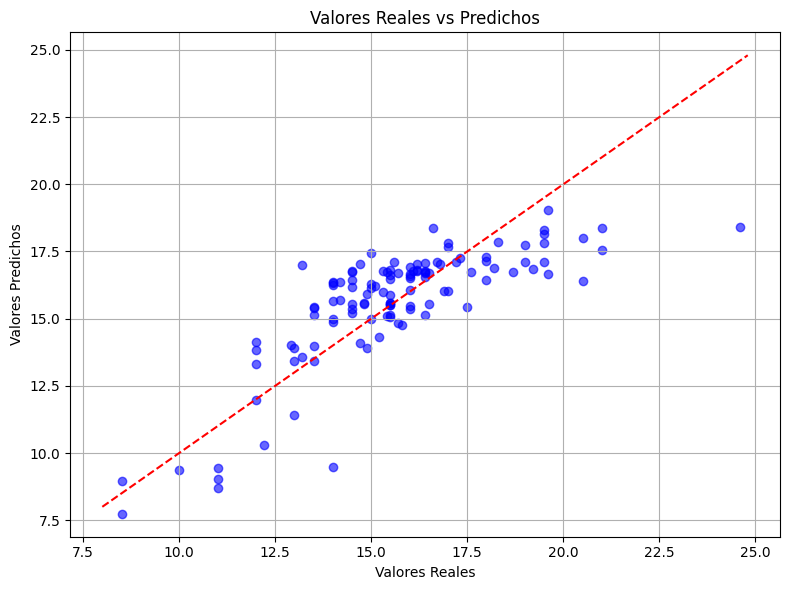

In [10]:
# Calcular el RMSE de las predicciones
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"\nRMSE de las predicciones: {rmse:.4f}")

# Calcular R² de las predicciones en el conjunto de prueba
r2 = r2_score(y_test, y_pred)
print(f"R² de las predicciones: {r2:.4f}")

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Valores Reales vs Predichos")
plt.tight_layout()
plt.grid()
plt.show()

## Supuestos del modelo
### 1. Linealidad

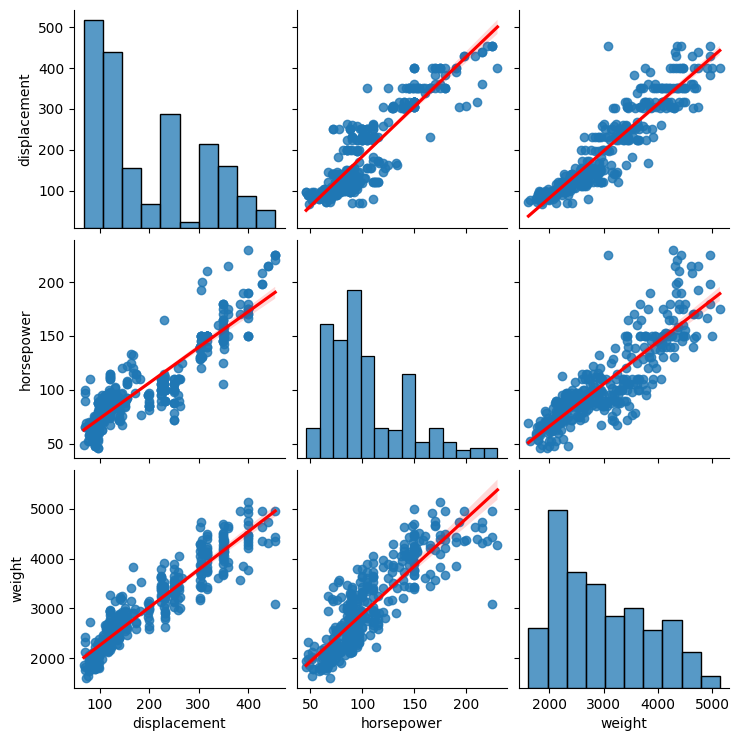

In [11]:
# Hacer pairplot de las variables numéricas
sns.pairplot(
    X,
    diag_kind="hist",
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}},
    corner=False,
)

### <span style="color:red">Interpretación</span>
Se observa linealidad entre las variables, ya que el ajuste lineal (línea roja) describe bastante bien los datos.

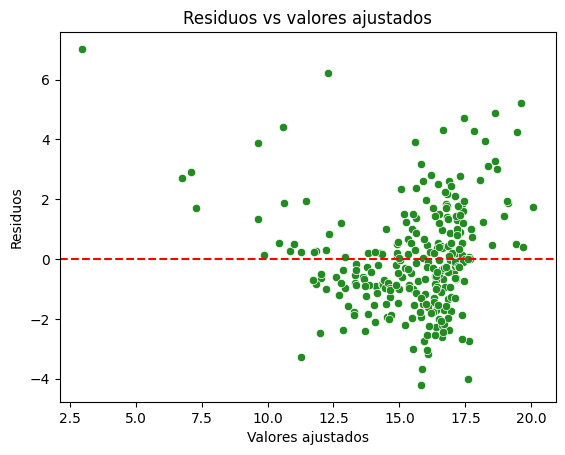

In [12]:
sns.scatterplot(x=model.fittedvalues, y=model.resid, color="forestgreen")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs valores ajustados")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.show()

### <span style="color:red">Interpretación</span>
De la gráfica se puede observar que la variable de salida no tiene un comportamiento lineal

### 2. Independencia

### <span style="color:red">Interpretación</span>
Desde el resumen estadístico del modelo de regresión lineal se concluyó que las variables son independientes.

### 3. Homoscedasticidad

In [13]:
bp = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan test p-value: {bp[1]:.4f}")
print(
    "Posible heteroscedasticidad"
    if bp[1] < 0.05
    else "No hay evidencia de heteroscedasticidad"
)

Breusch-Pagan test p-value: 0.0253
Posible heteroscedasticidad


### <span style="color:red">Interpretación</span>
Del criterio de Breusch-Pagan vemos que hay una posible heteroscedasticidad, lo que en el gráfico de residuos se observaría como un crecimiento acelerado en forma de embudo, de nuestro gráfico no podemos notar esa forma, por lo que vemos que la varianza de los errores aumentan o por lo menos varían de manera no lineal con el valor de la variable predictora

### 4. Normalidad

C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


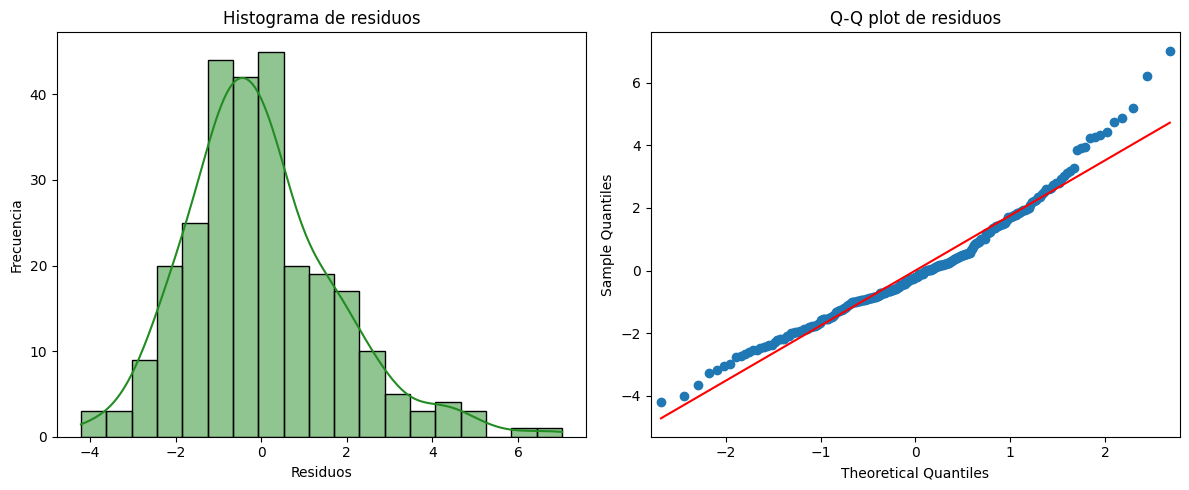

Prueba de Shapiro-Wilk: estadístico=0.9644, p-valor=0.0000


In [14]:
# Graficar histograma de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(model.resid, kde=True, color="forestgreen", ax=axes[0])
axes[0].set_title("Histograma de residuos")
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Frecuencia")

# Gráfico Q-Q plot de residuos
sm.qqplot(model.resid, line="s", ax=axes[1], color="steelblue")
axes[1].set_title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

# Prueba de Shapiro-Wilk
stat, p_value = shapiro(model.resid)
print(f"Prueba de Shapiro-Wilk: estadístico={stat:.4f}, p-valor={p_value:.4f}")

### <span style="color:red">Interpretación</span>
Del histograma de residuos podemos concluir que la distribución es ligeramente asimétrica, con una cola hacia la derecha. Del gráfico Q-Q vemos que hay desviaciones de la línea de referencia para valores altos, lo que sugiere que no se sigue una distribución normal. Finalmente de la prueba de Shapiro-Wilk obtenemos un p-valor de 0, por lo que no se cumple el supuesto de normalidad.

### 5. Multicolinealidad

In [15]:
print("Correlación entre predictores")
print(data[feat_names].corr(), "\n")

# Cálculo del VIF
vif = pd.DataFrame()
vif["Variable"] = feat_names
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(feat_names))]

print(vif, "\n")

# Índice de condición
U, s, Vt = svd(X_const)
cond_index = max(s) / min(s)

print(f"Índice de condición: {cond_index}")

Correlación entre predictores
              displacement  horsepower    weight
displacement      1.000000    0.897257  0.932994
horsepower        0.897257    1.000000  0.864538
weight            0.932994    0.864538  1.000000 

       Variable        VIF
0  displacement  31.128412
1    horsepower   9.836915
2        weight   4.918762 

Índice de condición: 17357.905479508667


### <span style="color:red">Interpretación</span>
Gracias a la matriz de correlación podemos ver valores cercanos a 1, los VIF son elevados, y el índice de condición supera el umbral crítico (>30).